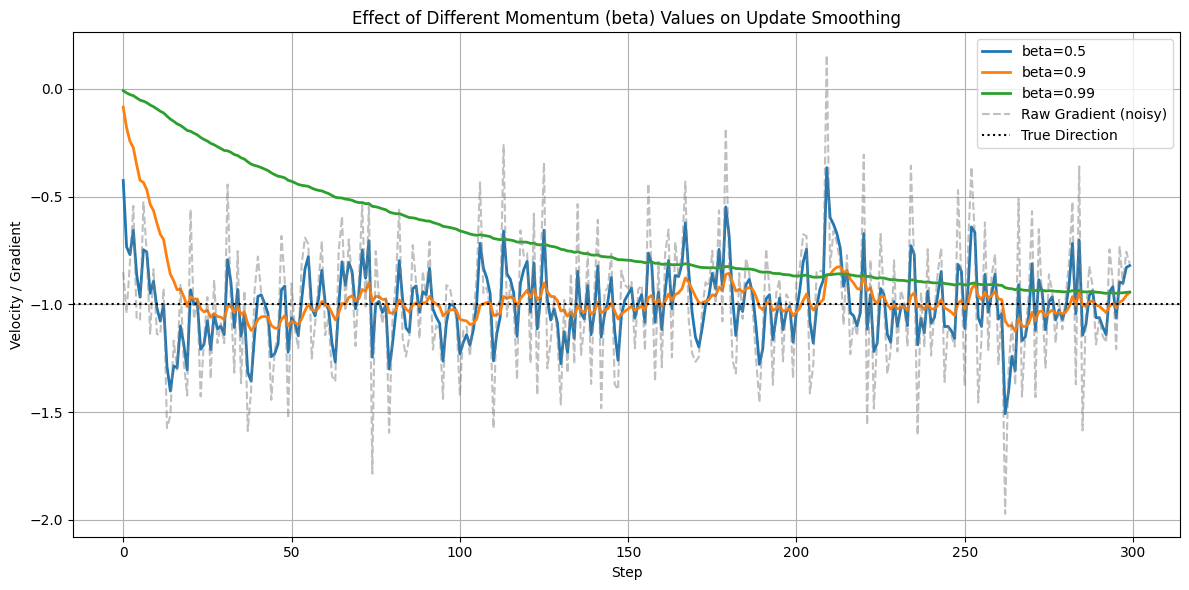

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate gradient directions with noise and reversal
np.random.seed(42)
timesteps = 300
true_direction = -1  # We want to go left
noise = np.random.normal(scale=0.3, size=timesteps)
gradients = true_direction + noise

# Simulate velocity updates for different beta values
betas = [0.5, 0.9, 0.99]
velocities = {beta: [] for beta in betas}
v = {beta: 0 for beta in betas}

for t in range(timesteps):
    g = gradients[t]
    for beta in betas:
        v[beta] = beta * v[beta] + (1 - beta) * g
        velocities[beta].append(v[beta])

# Plotting
plt.figure(figsize=(12, 6))
for beta in betas:
    plt.plot(velocities[beta], label=f'beta={beta}', linewidth=2)

plt.plot(gradients, '--', label='Raw Gradient (noisy)', color='gray', alpha=0.5)
plt.axhline(true_direction, color='black', linestyle=':', label='True Direction')
plt.xlabel('Step')
plt.ylabel('Velocity / Gradient')
plt.title('Effect of Different Momentum (beta) Values on Update Smoothing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
